# Entrega 2 — Detecção de Duplicatas

Cerca de 15% das manifestações são **duplicatas semânticas**: o mesmo problema, no mesmo local, descrito com palavras diferentes.
Detectá-las evita abrir vários chamados para o mesmo buraco e permite medir a real demanda por problema.

Neste notebook:

1. implementamos `detectar_duplicatas(textos, limiar=0.85)`;
2. geramos a matriz de similaridade completa (heatmap);
3. calibramos e justificamos o limiar, comparando o valor fixo (0,85), o limiar dinâmico por percentil e um limiar calibrado;
4. analisamos falsos positivos e falsos negativos em relação às duplicatas reais do dataset.

> O arquivo `gabarito_duplicatas.json` contém os 6 pares de duplicatas reais do dataset de exemplo (6 de 40 manifestações = 15%).

## 1. Configuração

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from sentence_transformers import SentenceTransformer
from transformers.utils import logging as hf_logging
from huggingface_hub.utils import disable_progress_bars, logging as hub_logging

hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()
disable_progress_bars()
hub_logging.set_verbosity_error()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

pd.set_option("display.max_colwidth", 110)
sns.set_theme(style="whitegrid")

MODELOS = {
    "MiniLM": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "mpnet": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
}

In [2]:
with open("manifestacoes.json", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))
with open("gabarito_duplicatas.json", encoding="utf-8") as f:
    GABARITO = {tuple(sorted(par)) for par in json.load(f)["pares"]}

ids = df["id"].tolist()
textos = df["texto"].tolist()
pos = {id_: i for i, id_ in enumerate(ids)}
print(f"{len(df)} manifestações | {len(GABARITO)} pares de duplicatas reais:")
for a, b in sorted(GABARITO):
    print(f"  {a}: {df.loc[pos[a], 'texto'][:80]}...")
    print(f"  {b}: {df.loc[pos[b], 'texto'][:80]}...\n")

40 manifestações | 6 pares de duplicatas reais:
  M003: Tem um buraco enorme na Av. Brasil, perto do cruzamento com a Rua XV. Os carros ...
  M017: Asfalto todo esburacado da avenida principal (Av. Brasil), principalmente perto ...

  M008: Posto de saúde sem médico no Jardim América há duas semanas. Chegamos cedo e vol...
  M022: Falta atendimento no PSF do Jardim América: a unidade está sem clínico geral faz...

  M010: O bar da esquina da Rua Goiás com a Rua Pará toca som alto até as 3 da manhã, to...
  M029: Barulho absurdo toda madrugada de sexta e sábado no bar da Rua Goiás, esquina co...

  M012: O poste da Rua das Flores, em frente ao número 45, está apagado há um mês. A rua...
  M035: Rua das Flores completamente às escuras: a iluminação pública em frente ao númer...

  M014: Os assaltos no ponto de ônibus do Terminal Central estão frequentes. Levaram o c...
  M038: Terminal Central perigoso: no ponto de ônibus os ladrões agem todo fim de tarde....

  M019: Está faltando meren

## 2. A função `detectar_duplicatas`

A função gera os embeddings (normalizados), calcula a matriz de cosseno e devolve todos os pares `i < j` com similaridade **≥ limiar**, do mais
parecido para o menos parecido. O modelo é carregado uma única vez e reaproveitado entre chamadas.

In [3]:
_cache_modelos = {}


def carregar_modelo(nome="MiniLM"):
    """Carrega (uma única vez) o modelo de embeddings pelo apelido definido em MODELOS."""
    if nome not in _cache_modelos:
        _cache_modelos[nome] = SentenceTransformer(MODELOS[nome])
    return _cache_modelos[nome]


def matriz_similaridade(textos, modelo="MiniLM"):
    """Matriz n x n de similaridade de cosseno entre os textos."""
    E = carregar_modelo(modelo).encode(textos, normalize_embeddings=True)
    return E @ E.T  # vetores normalizados: produto escalar = cosseno


def detectar_duplicatas(textos, limiar=0.85, modelo="MiniLM"):
    """Retorna os pares (i, j, similaridade) com i < j e similaridade >= limiar,
    ordenados da maior para a menor similaridade."""
    S = matriz_similaridade(textos, modelo)
    i, j = np.triu_indices(len(textos), k=1)
    mask = S[i, j] >= limiar
    pares = [(int(a), int(b), float(s)) for a, b, s in zip(i[mask], j[mask], S[i, j][mask])]
    return sorted(pares, key=lambda p: -p[2])


# Uso com o limiar padrão pedido no enunciado
for modelo in MODELOS:
    achados = detectar_duplicatas(textos, limiar=0.85, modelo=modelo)
    print(f"{modelo} com limiar 0,85 -> {len(achados)} par(es):",
          [(ids[a], ids[b], round(s, 3)) for a, b, s in achados])

MiniLM com limiar 0,85 -> 0 par(es): []


mpnet com limiar 0,85 -> 2 par(es): [('M012', 'M035', 0.886), ('M014', 'M038', 0.866)]


Com o limiar padrão de 0,85, o MiniLM praticamente não encontra duplicatas e o mpnet encontra poucas.
Antes de escolher outro valor, olhamos a matriz completa e a distribuição das similaridades.

## 3. Matriz de similaridade completa (heatmap)

As manifestações estão ordenadas por categoria oficial, e os pares duplicados reais aparecem destacados com um quadrado preto.

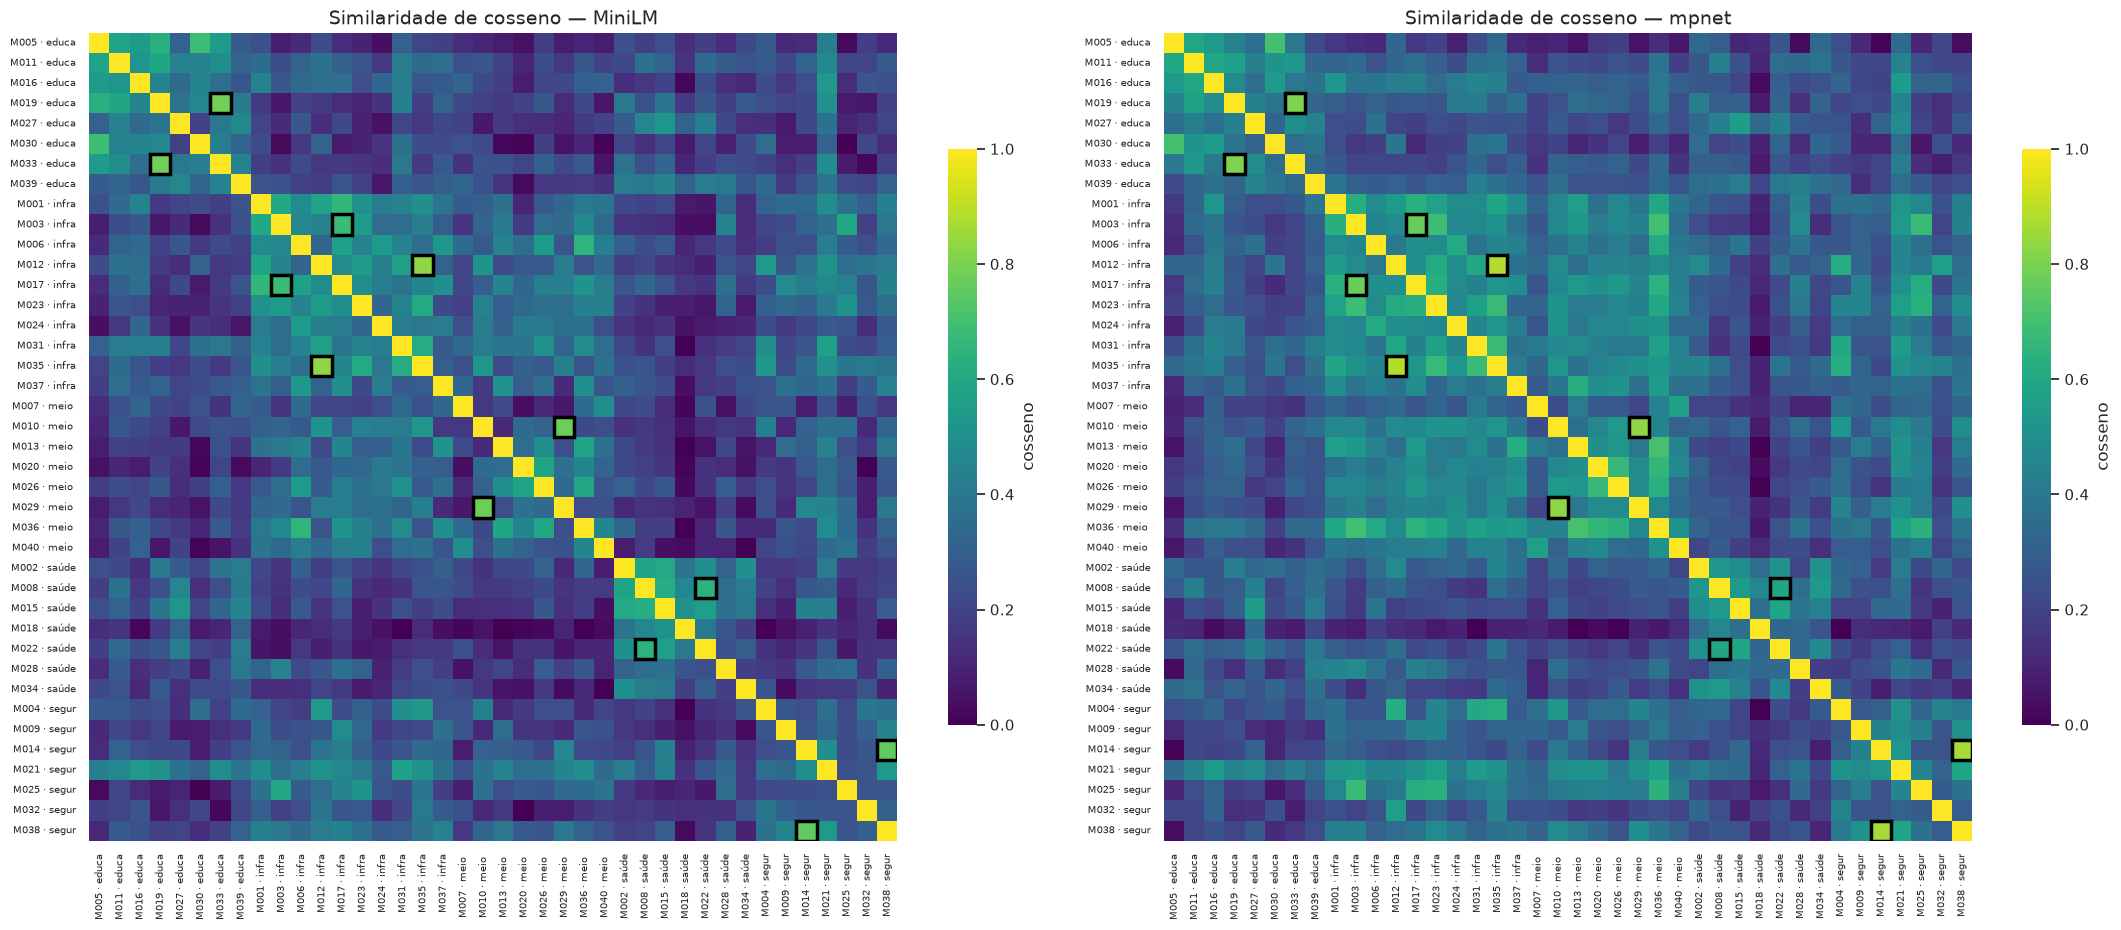

In [4]:
S = {m: matriz_similaridade(textos, m) for m in MODELOS}

ordem = df.sort_values(["categoria_oficial", "id"]).index.to_numpy()
rotulos = [f"{ids[i]} · {df.loc[i, 'categoria_oficial'][:5]}" for i in ordem]
rank = {i: r for r, i in enumerate(ordem)}

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, (m, M) in zip(axes, S.items()):
    sns.heatmap(M[np.ix_(ordem, ordem)], ax=ax, cmap="viridis", vmin=0, vmax=1, square=True,
                xticklabels=rotulos, yticklabels=rotulos, cbar_kws={"shrink": 0.6, "label": "cosseno"})
    for a, b in GABARITO:
        for r, c in [(rank[pos[a]], rank[pos[b]]), (rank[pos[b]], rank[pos[a]])]:
            ax.add_patch(Rectangle((c, r), 1, 1, fill=False, edgecolor="black", lw=2.5))
    ax.set_title(f"Similaridade de cosseno — {m}", fontsize=14)
    ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig("figuras/e2_heatmap.png", dpi=120)
plt.show()

Os blocos mais claros na diagonal mostram que manifestações da mesma categoria tendem a ser mais parecidas entre si, mas nem sempre as
duplicatas reais (quadrados pretos) são as células mais claras da linha, principalmente no MiniLM.

## 4. Distribuição das similaridades e escolha do limiar

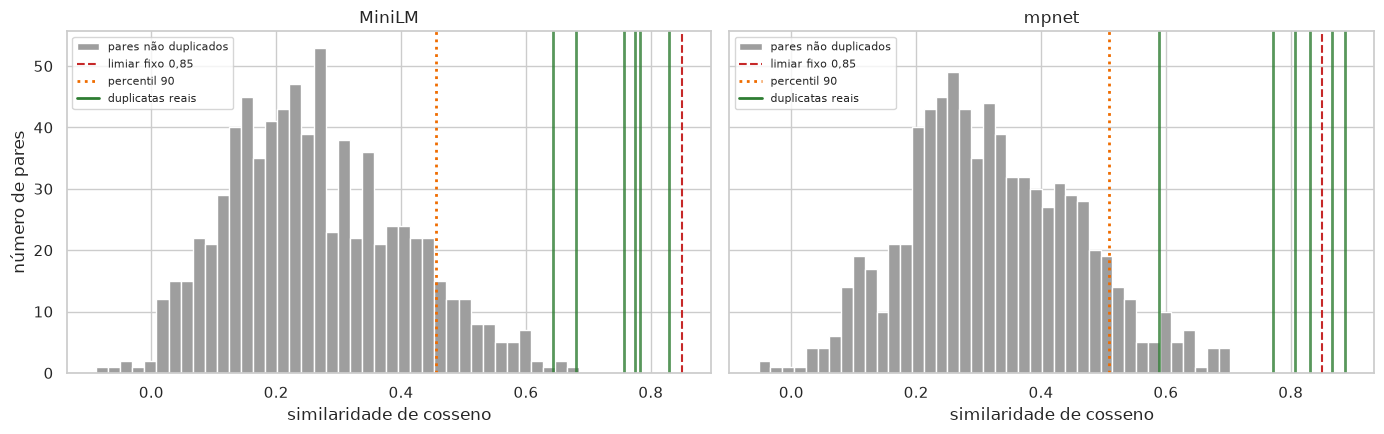

,MiniLM,mpnet
média (todos os pares),0.266,0.326
percentil 90,0.457,0.509
percentil 99,0.644,0.688
menor duplicata real,0.643,0.589
maior não-duplicata,0.686,0.703


In [5]:
iu = np.triu_indices(len(df), k=1)
eh_dup = np.array([(tuple(sorted((ids[i], ids[j]))) in GABARITO) for i, j in zip(*iu)])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, (m, M) in zip(axes, S.items()):
    v = M[iu]
    ax.hist(v[~eh_dup], bins=40, color="#9e9e9e", label="pares não duplicados")
    for x in v[eh_dup]:
        ax.axvline(x, color="#2e7d32", lw=2, alpha=0.8)
    ax.axvline(0.85, color="#c62828", ls="--", label="limiar fixo 0,85")
    ax.axvline(np.percentile(v, 90), color="#ef6c00", ls=":", lw=2, label="percentil 90")
    ax.plot([], [], color="#2e7d32", lw=2, label="duplicatas reais")
    ax.set_title(m)
    ax.set_xlabel("similaridade de cosseno")
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("número de pares")
plt.tight_layout()
plt.savefig("figuras/e2_distribuicao.png", dpi=150)
plt.show()

resumo = pd.DataFrame({
    m: {
        "média (todos os pares)": M[iu].mean(),
        "percentil 90": np.percentile(M[iu], 90),
        "percentil 99": np.percentile(M[iu], 99),
        "menor duplicata real": M[iu][eh_dup].min(),
        "maior não-duplicata": M[iu][~eh_dup].max(),
    } for m, M in S.items()
}).round(3)
resumo

### 4.1 Varredura de limiares: precisão, revocação e F1

Para cada limiar, comparamos os pares detectados com o gabarito:

* **precisão** = dos pares apontados, quantos são duplicatas de verdade (falsos positivos derrubam a precisão);
* **revocação** = das duplicatas reais, quantas foram encontradas (falsos negativos derrubam a revocação).

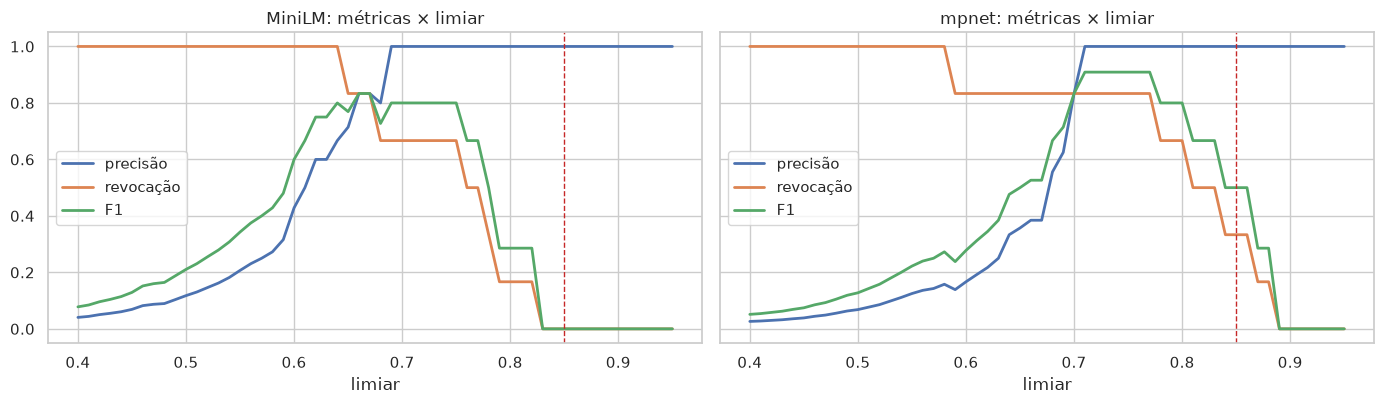

,modelo,limiar,VP,FP,FN,precisão,revocação,F1
93,mpnet,0.77,5,0,1,1.000,0.833,0.909
92,mpnet,0.76,5,0,1,1.000,0.833,0.909
91,mpnet,0.75,5,0,1,1.000,0.833,0.909
27,MiniLM,0.67,5,1,1,0.833,0.833,0.833
26,MiniLM,0.66,5,1,1,0.833,0.833,0.833
35,MiniLM,0.75,4,0,2,1.000,0.667,0.800


In [6]:
def avaliar(pares_detectados):
    detectados = {tuple(sorted((ids[a], ids[b]))) for a, b, _ in pares_detectados}
    vp = len(detectados & GABARITO)
    fp = len(detectados - GABARITO)
    fn = len(GABARITO - detectados)
    precisao = vp / (vp + fp) if vp + fp else 1.0
    revocacao = vp / (vp + fn)
    f1 = 2 * precisao * revocacao / (precisao + revocacao) if precisao + revocacao else 0.0
    return {"VP": vp, "FP": fp, "FN": fn, "precisão": precisao, "revocação": revocacao, "F1": f1}


def pares_acima(M, limiar):
    i, j = np.triu_indices(len(M), k=1)
    mask = M[i, j] >= limiar
    return list(zip(i[mask], j[mask], M[i, j][mask]))


limiares = np.round(np.arange(0.40, 0.951, 0.01), 2)
varredura = pd.concat({m: pd.DataFrame([avaliar(pares_acima(M, t)) for t in limiares], index=limiares)
                       for m, M in S.items()}, names=["modelo", "limiar"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
for ax, m in zip(axes, S):
    varredura.loc[m][["precisão", "revocação", "F1"]].plot(ax=ax, lw=2)
    ax.axvline(0.85, color="#c62828", ls="--", lw=1)
    ax.set_title(f"{m}: métricas × limiar")
    ax.set_xlabel("limiar")
plt.tight_layout()
plt.savefig("figuras/e2_varredura.png", dpi=150)
plt.show()

melhores = varredura.reset_index().sort_values(["F1", "precisão", "limiar"], ascending=[False, False, False])
melhores.groupby("modelo").head(3).round(3)

### 4.2 Comparação das estratégias de limiar

In [7]:
LIMIAR_ESCOLHIDO = 0.75
MODELO_ESCOLHIDO = "mpnet"

estrategias = []
for m, M in S.items():
    for nome, t in [("fixo 0,85 (enunciado)", 0.85),
                    ("dinâmico: percentil 90", np.percentile(M[iu], 90)),
                    ("dinâmico: percentil 99", np.percentile(M[iu], 99)),
                    (f"calibrado ({LIMIAR_ESCOLHIDO})", LIMIAR_ESCOLHIDO)]:
        estrategias.append({"modelo": m, "estratégia": nome, "limiar": round(float(t), 3),
                            **avaliar(pares_acima(M, t))})
pd.DataFrame(estrategias).set_index(["modelo", "estratégia"]).round(3)

limiar  VP  FP  FN  precisão  revocação     F1
modelo estratégia                                                            
MiniLM fixo 0,85 (enunciado)    0.850   0   0   6     1.000      0.000  0.000
       dinâmico: percentil 90   0.457   6  72   0     0.077      1.000  0.143
       dinâmico: percentil 99   0.644   5   3   1     0.625      0.833  0.714
       calibrado (0.75)         0.750   4   0   2     1.000      0.667  0.800
mpnet  fixo 0,85 (enunciado)    0.850   2   0   4     1.000      0.333  0.500
       dinâmico: percentil 90   0.509   6  72   0     0.077      1.000  0.143
       dinâmico: percentil 99   0.688   5   3   1     0.625      0.833  0.714
       calibrado (0.75)         0.750   5   0   1     1.000      0.833  0.909

### 4.3 Justificativa do limiar escolhido: **0,75 com o modelo mpnet**

* **O valor fixo de 0,85 é conservador demais para estes modelos.** Ele tem precisão perfeita, mas encontra apenas 0 (MiniLM) e 2 (mpnet) das 6 duplicatas. Paráfrases reais de cidadãos raramente passam de 0,85, pois cada pessoa acrescenta detalhes diferentes ("já estourei um pneu", "já liguei várias vezes").
* **O limiar dinâmico pelo percentil 90 é permissivo demais.** Como só ~0,8% dos 780 pares são duplicatas (6/780), o percentil 90 (0,46–0,51) marca 78 pares, sendo 72 falsos positivos (precisão de 7,7%). O percentil só faz sentido se for alto o suficiente para refletir a taxa real de duplicatas; mesmo o percentil 99 ainda gera 3 falsos positivos.
* **Com o mpnet, há uma faixa "limpa" entre 0,71 e 0,77**: acima da maior não-duplicata (0,703) e abaixo da duplicata mais fraca que ele ainda reconhece (0,771). Qualquer valor nessa faixa dá precisão 100% e revocação 83% (F1 = 0,91). Escolhemos **0,75**, perto do meio da faixa, para ter margem dos dois lados em vez de encostar no limite que os dados de treino sugerem.
* **Por que o mpnet e não o MiniLM:** no MiniLM, as duplicatas reais e os pares mais parecidos entre as não-duplicatas se sobrepõem (menor duplicata 0,643 × maior não-duplicata 0,686). Nenhum limiar separa as duas classes, e o melhor F1 é 0,83. O mpnet separa melhor a classe positiva, ao custo de ser um modelo maior (768 dimensões contra 384) e mais lento, o que é irrelevante para um volume de 4.000 manifestações por mês.
* **Critério de negócio:** para a ouvidoria, um falso positivo significa **fundir duas reclamações diferentes** e deixar um cidadão sem resposta, o que é pior que um falso negativo (um chamado duplicado que o atendente ainda pode juntar manualmente). Por isso priorizamos a precisão.


## 5. Pares duplicados encontrados

In [8]:
encontrados = detectar_duplicatas(textos, limiar=LIMIAR_ESCOLHIDO, modelo=MODELO_ESCOLHIDO)
pd.DataFrame([{
    "par": f"{ids[a]} × {ids[b]}",
    "similaridade": round(s, 3),
    "duplicata real?": "sim" if tuple(sorted((ids[a], ids[b]))) in GABARITO else "NÃO",
    "texto 1": textos[a],
    "texto 2": textos[b],
} for a, b, s in encontrados])

,par,similaridade,duplicata real?,texto 1,texto 2
0,M012 × M035,0.886,sim,"O poste da Rua das Flores, em frente ao número 45, está apagado há um mês. A rua fica totalmente escura à ...",Rua das Flores completamente às escuras: a iluminação pública em frente ao número 45 não funciona há semanas.
1,M014 × M038,0.866,sim,Os assaltos no ponto de ônibus do Terminal Central estão frequentes. Levaram o celular da minha filha onte...,Terminal Central perigoso: no ponto de ônibus os ladrões agem todo fim de tarde. Já presenciei dois roubos...
2,M010 × M029,0.831,sim,"O bar da esquina da Rua Goiás com a Rua Pará toca som alto até as 3 da manhã, todos os fins de semana. Nin...","Barulho absurdo toda madrugada de sexta e sábado no bar da Rua Goiás, esquina com a Pará. Música alta até ..."
3,M019 × M033,0.807,sim,Está faltando merenda na Escola Municipal Monteiro Lobato. As crianças estão recebendo só bolacha e suco n...,"Os alunos da Monteiro Lobato estão sem merenda escolar. Meu filho volta com fome todos os dias, só dão bis..."
4,M003 × M017,0.771,sim,"Tem um buraco enorme na Av. Brasil, perto do cruzamento com a Rua XV. Os carros desviam em cima da hora e ...","Asfalto todo esburacado da avenida principal (Av. Brasil), principalmente perto da Rua XV. Já estourei um ..."


## 6. Análise de falsos positivos e falsos negativos

Para entender os erros, listamos (a) as duplicatas reais que ficaram abaixo do limiar e (b) os pares não duplicados com maior similaridade —
os "quase falsos positivos" que um limiar um pouco menor passaria a aceitar.

In [9]:
M = S[MODELO_ESCOLHIDO]
detectados = {tuple(sorted((ids[a], ids[b]))) for a, b, _ in encontrados}


def linha(a, b):
    return {"par": f"{a} × {b}", "similaridade": round(float(M[pos[a], pos[b]]), 3),
            "texto 1": df.loc[pos[a], "texto"], "texto 2": df.loc[pos[b], "texto"]}


falsos_negativos = pd.DataFrame([linha(a, b) for a, b in sorted(GABARITO - detectados)])
print(f"Falsos negativos ({len(falsos_negativos)}): duplicatas reais abaixo de {LIMIAR_ESCOLHIDO}")
falsos_negativos

Falsos negativos (1): duplicatas reais abaixo de 0.75


,par,similaridade,texto 1,texto 2
0,M008 × M022,0.589,Posto de saúde sem médico no Jardim América há duas semanas. Chegamos cedo e voltamos para casa sem atendi...,Falta atendimento no PSF do Jardim América: a unidade está sem clínico geral faz quinze dias e mandam todo...


In [10]:
nao_dup = sorted(((M[i, j], ids[i], ids[j]) for i, j in zip(*iu)
                  if tuple(sorted((ids[i], ids[j]))) not in GABARITO), reverse=True)[:6]
quase_fp = pd.DataFrame([linha(a, b) for _, a, b in nao_dup])
quase_fp.insert(1, "categoria", [f"{df.loc[pos[a], 'categoria_oficial']} / {df.loc[pos[b], 'categoria_oficial']}"
                                 for _, a, b in nao_dup])
print(f"Pares NÃO duplicados mais similares (falsos positivos em potencial) — {MODELO_ESCOLHIDO}")
quase_fp

Pares NÃO duplicados mais similares (falsos positivos em potencial) — mpnet


,par,categoria,similaridade,texto 1,texto 2
0,M013 × M036,meio ambiente / meio ambiente,0.703,Tem gente jogando entulho e lixo no terreno baldio da Rua Amazonas. Já apareceram ratos e escorpiões.,"Há um lixão clandestino se formando na estrada vicinal que liga o bairro São Cristóvão à zona rural, perto..."
1,M005 × M030,educação / educação,0.699,A Escola Municipal Castro Alves está sem professor de matemática desde o início do semestre. Os alunos fic...,A biblioteca da Escola Municipal Castro Alves está fechada porque não tem funcionário. Os alunos não conse...
2,M003 × M036,infraestrutura / meio ambiente,0.696,"Tem um buraco enorme na Av. Brasil, perto do cruzamento com a Rua XV. Os carros desviam em cima da hora e ...","Há um lixão clandestino se formando na estrada vicinal que liga o bairro São Cristóvão à zona rural, perto..."
3,M003 × M023,infraestrutura / infraestrutura,0.686,"Tem um buraco enorme na Av. Brasil, perto do cruzamento com a Rua XV. Os carros desviam em cima da hora e ...",O semáforo do cruzamento da Av. Independência com a Rua Bahia está piscando amarelo há três dias. Muito pe...
4,M003 × M025,infraestrutura / segurança,0.677,"Tem um buraco enorme na Av. Brasil, perto do cruzamento com a Rua XV. Os carros desviam em cima da hora e ...","Carros em alta velocidade na Rua Minas Gerais, em frente à creche. Precisamos de lombada ou radar."
5,M031 × M035,infraestrutura / infraestrutura,0.676,"Lâmpada queimada na praça do bairro São Cristóvão, perto do parquinho. As crianças não conseguem brincar d...",Rua das Flores completamente às escuras: a iluminação pública em frente ao número 45 não funciona há semanas.


In [11]:
# Como cada modelo trata os casos difíceis
casos = [("M008", "M022"), ("M003", "M017")] + [(a, b) for _, a, b in nao_dup[:4]]
pd.DataFrame({m: {f"{a} × {b}" + (" (dup)" if tuple(sorted((a, b))) in GABARITO else ""): M_[pos[a], pos[b]]
                  for a, b in casos} for m, M_ in S.items()}).round(3)

,MiniLM,mpnet
M008 × M022 (dup),0.643,0.589
M003 × M017 (dup),0.680,0.771
M013 × M036,0.594,0.703
M005 × M030,0.686,0.699
M003 × M036,0.467,0.696
M003 × M023,0.550,0.686


## 7. Extensão: regra híbrida (embedding + termos exatos)

Os erros acima sugerem uma melhoria: duplicatas reais falam do **mesmo local**, e nomes de ruas, bairros e unidades são justamente o que
as representações esparsas capturam bem (Entrega 1). Testamos uma regra em dois níveis:

* similaridade semântica **≥ limiar calibrado** → duplicata; ou
* similaridade semântica **≥ 0,55** *e* TF-IDF **≥ 0,20** (compartilham termos específicos, como o endereço) → duplicata.

⚠️ Os valores 0,55 e 0,20 foram escolhidos olhando os mesmos 6 pares do gabarito, então o resultado abaixo é otimista (risco de sobreajuste).
Em produção, eles precisariam ser validados em um conjunto maior de manifestações rotuladas.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


def detectar_duplicatas_hibrido(textos, limiar=LIMIAR_ESCOLHIDO, limiar_sem=0.55, limiar_tfidf=0.20,
                                modelo=MODELO_ESCOLHIDO):
    """Duplicata se a similaridade semântica for alta OU se for moderada e os textos compartilharem termos exatos."""
    S_sem = matriz_similaridade(textos, modelo)
    S_tfidf = cosine_similarity(TfidfVectorizer().fit_transform(textos))
    i, j = np.triu_indices(len(textos), k=1)
    mask = (S_sem[i, j] >= limiar) | ((S_sem[i, j] >= limiar_sem) & (S_tfidf[i, j] >= limiar_tfidf))
    return sorted([(int(a), int(b), float(S_sem[a, b])) for a, b in zip(i[mask], j[mask])], key=lambda p: -p[2])


hibrido = detectar_duplicatas_hibrido(textos)
print("Regra híbrida:", avaliar(hibrido))
print("Somente embedding:", avaliar(encontrados))
pd.DataFrame([{"par": f"{ids[a]} × {ids[b]}", "semântica": round(s, 3),
               "duplicata real?": "sim" if tuple(sorted((ids[a], ids[b]))) in GABARITO else "NÃO"}
              for a, b, s in hibrido])

Regra híbrida: {'VP': 6, 'FP': 1, 'FN': 0, 'precisão': 0.8571428571428571, 'revocação': 1.0, 'F1': 0.923076923076923}
Somente embedding: {'VP': 5, 'FP': 0, 'FN': 1, 'precisão': 1.0, 'revocação': 0.8333333333333334, 'F1': 0.9090909090909091}


,par,semântica,duplicata real?
0,M012 × M035,0.886,sim
1,M014 × M038,0.866,sim
2,M010 × M029,0.831,sim
3,M019 × M033,0.807,sim
4,M003 × M017,0.771,sim
5,M005 × M030,0.699,NÃO
6,M008 × M022,0.589,sim


## 8. Discussão e conclusão

**Falsos negativos.** Com mpnet e limiar 0,75, a única duplicata real perdida é **M008 × M022** (0,589): "Posto de saúde sem médico… sem atendimento" × "Falta atendimento no PSF… sem clínico geral". O modelo não relaciona "PSF" (Programa Saúde da Família) a "posto de saúde", nem "clínico geral" a "médico" com força suficiente. É o mesmo problema observado na Entrega 1: siglas e jargão da administração pública são um ponto cego dos modelos genéricos. No MiniLM, esse par (0,643) e M003 × M017 (0,680) também ficam abaixo de qualquer limiar sem falsos positivos.

**Falsos positivos (em potencial).** Nenhum par não-duplicado passou de 0,75, mas os mais próximos revelam dois padrões perigosos:

1. **Mesmo local, problema diferente:** M005 × M030 (0,699) são duas reclamações sobre a Escola Municipal Castro Alves, uma sobre falta de professor e outra sobre a biblioteca fechada. Um embedding de sentença mistura "onde" e "o quê" num único vetor, então compartilhar o local aproxima textos que pedem ações diferentes.
2. **Mesmo tipo de problema, lugar diferente:** M013 × M036 (0,703), sobre descarte de lixo em um terreno baldio e em um lixão clandestino, e M003 × M023/M025 (buraco × semáforo × excesso de velocidade, todos sobre trânsito). São temas relacionados, que devem ficar no mesmo *cluster*, mas não são o mesmo chamado.

A regra híbrida (seção 7) ataca o primeiro problema, porque exige coincidência de termos exatos (endereços) quando a similaridade semântica é só moderada. Ela recupera M008 × M022 graças a "Jardim América" e acerta 6 de 6, mas continua errando M005 × M030, que é justamente o caso "mesmo local, problema diferente".

**Conclusões:**

* Não existe um limiar universal: ele depende do modelo (as distribuições de similaridade são diferentes) e do custo relativo de cada tipo de erro. O 0,85 do enunciado é um ponto de partida razoável para o mpnet se a prioridade for zero falsos positivos, mas sacrifica 2/3 das duplicatas.
* Limiares dinâmicos por percentil precisam ser coerentes com a **taxa esperada de duplicatas**: o percentil 90 assume que 10% dos *pares* são duplicados, quando o real é inferior a 1%.
* Com apenas 6 pares positivos, qualquer calibragem tem alta variância. Em produção, recomenda-se: (1) rotular uma amostra maior de manifestações reais para recalibrar o limiar; (2) usar uma **zona cinzenta** (por exemplo, 0,60–0,75) em que o sistema *sugere* a possível duplicata para um atendente confirmar, em vez de fundir automaticamente; e (3) extrair o endereço ou unidade como campo separado, para distinguir "mesmo problema no mesmo lugar" de "mesmo problema em outro lugar".
